## Retail Data Analytics with PySpark


In [0]:
# Start Spark session and import dependencies
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as _sum, count, when, to_timestamp, date_format, expr, percent_rank
from pyspark.sql import Window
#from pyspark.sql.types import *
#from pyspark.sql.functions import *

In [0]:
df = spark.table('hive_metastore.default.retail')

df = df.withColumn("InvoiceDateTS", to_timestamp("InvoiceDate", "MM/d/yyyy HH:mm")) \
       .withColumn("date_yyyymm", date_format("InvoiceDateTS", "yyyyMM"))


In [0]:
# Display schema, record count, and summary statistics
df.printSchema()
print(f"Total records: {df.count()}")
display(df.describe())


root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: decimal(10,0) (nullable = true)
 |-- Country: string (nullable = true)
 |-- InvoiceDateTS: timestamp (nullable = true)
 |-- date_yyyymm: string (nullable = true)

Total records: 1067371


summary,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,date_yyyymm
count,1067371,1067371,1062989,1067371,1067371,824364,1067371,1067371
mean,537608.1499316233,28350.201592689715,21848.25,9.9388984711033,4.6493877274113755,15324.6385,null,201050.05001072728
stddev,26662.45044690485,17968.479697262945,922.9197780233488,172.70579407675257,123.55305872146307,1697.4644503793088,null,56.887301167158974
min,489434,10002,DOORMAT UNION JACK GUNS AND ROSES,-80995,-53594.36,12346,Australia,200912
max,C581569,m,wrongly sold sets,80995,38970.0,18287,West Indies,201112


#### Total Invoice Amount Distribution

- We compute the line‐level amount per row, then aggregate to get the total per invoice.

In [0]:
# Calculate line amount and total per invoice
from pyspark.sql.functions import col

# compute line_amount
df = df.withColumn("line_amount", col("Quantity") * col("Price"))

# total per invoice
invoice_totals = df.groupBy("Invoice") \
                   .agg(_sum("line_amount").alias("total_amount"))

# show top 5
display(invoice_totals.head(5))

Invoice,total_amount
489677,192.0
491045,303.2
491658,155.05999999999997
493542,118.75
493977,275.95


#### Monthly Placed and Canceled Orders

- We separate canceled orders (Invoice starts with ‘C’) from placed ones, normalize IDs, and count orders per month before merging into one DataFrame and plotting trends.

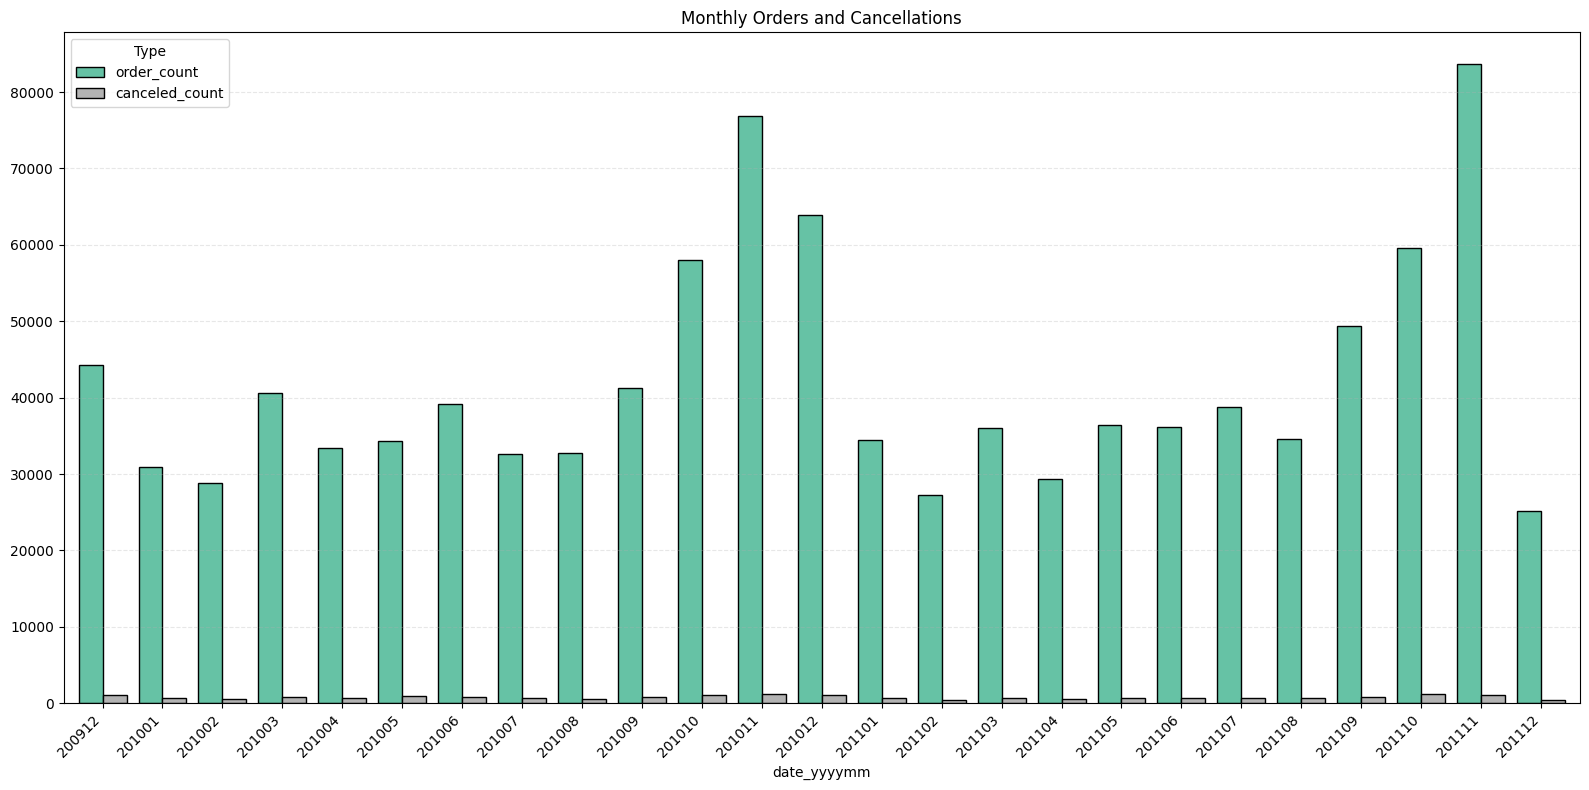

In [0]:
# Identify placed vs canceled, count per YYYYMM and plot via Pandas
from matplotlib import pyplot as plt

# canceled invoices
canceled = df.filter(col("Invoice").startswith("C")) \
             .withColumn("InvoiceID", expr("substring(Invoice, 2, length(Invoice)-1)"))

# placed invoices exclude canceled
placed = df.filter(~col("Invoice").startswith("C")) \
           .filter(~col("Invoice").isin([row.InvoiceID for row in canceled.select("InvoiceID").distinct().collect()]))

# monthly counts
placed_cnt = placed.groupBy("date_yyyymm").agg(count("Invoice").alias("order_count"))
canceled_cnt = canceled.groupBy("date_yyyymm").agg(count("Invoice").alias("canceled_count"))

# merge and plot
monthly = placed_cnt.join(canceled_cnt, "date_yyyymm", "outer").orderBy("date_yyyymm")
pdf = monthly.toPandas()
pdf.plot(x="date_yyyymm", y=["order_count","canceled_count"],
         kind="bar", figsize=(16,8), width=0.8, colormap="Set2",
         title="Monthly Orders and Cancellations", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.legend(title="Type")
plt.show()


#### Monthly Sales
- Aggregate total monthly revenue by summing line amounts, then visualize the time series of sales.

In [0]:
monthly_sales = df.groupBy("date_yyyymm") \
                  .agg(_sum("line_amount").alias("total_sales")) \
                  .orderBy("date_yyyymm")
ms_pdf = monthly_sales.toPandas()
ms_pdf['date_yyyymm'] = pd.to_datetime(ms_pdf['date_yyyymm'], format="%Y%m")

display(monthly_sales.head(10))

date_yyyymm,total_sales
200912,799847.1100000143
201001,624032.8919999956
201002,533091.4260000042
201003,765848.7609999765
201004,590580.4319999823
201005,615322.8300000005
201006,679786.6099999842
201007,575236.3600000101
201008,656776.3399999854
201009,853650.4309999745


#### Monthly Sales Growth

In [0]:
# Compute and plot monthly sales growth rate
ms_pdf['growth_rate'] = ms_pdf['total_sales'].pct_change() * 100
display(ms_pdf.head(11))


date_yyyymm,total_sales,growth_rate
2009-12-01T00:00:00Z,799847.1100000143,null
2010-01-01T00:00:00Z,624032.8919999956,-21.980978089677116
2010-02-01T00:00:00Z,533091.4260000042,-14.573184709627785
2010-03-01T00:00:00Z,765848.7609999765,43.66180426994348
2010-04-01T00:00:00Z,590580.4319999823,-22.885501410375664
2010-05-01T00:00:00Z,615322.8300000005,4.1895052154418355
2010-06-01T00:00:00Z,679786.6099999842,10.476416095268814
2010-07-01T00:00:00Z,575236.3600000101,-15.379863101448333
2010-08-01T00:00:00Z,656776.3399999854,14.175039282978187
2010-09-01T00:00:00Z,853650.4309999745,29.975819622246668


#### Monthly Active Users

- Count unique customers each month to track engagement trends.


In [0]:
# Unique active customers per month and bar plot
monthly_users = df.groupBy("date_yyyymm") \
                  .agg(expr("count(DISTINCT `Customer ID`)").alias("active_users")) \
                  .orderBy("date_yyyymm")

display(monthly_users.head(10))

date_yyyymm,active_users
200912,1045
201001,786
201002,807
201003,1111
201004,998
201005,1062
201006,1095
201007,988
201008,964
201009,1202


#### New and Existing Users
- Identify each customer’s first purchase month, label transactions as New or Existing, and tabulate counts by user type and purchase month.


In [0]:
# Tag users as New vs Existing and count per month
first_purchase = df.groupBy("Customer ID") \
                   .agg(expr("min(date_yyyymm)").alias("first_month"))

df2 = df.join(first_purchase, on="Customer ID") \
        .withColumn("user_type",
            when(col("date_yyyymm") == col("first_month"), "New")
            .otherwise("Existing"))

user_counts = df2.groupBy("first_month", "user_type") \
                 .agg(expr("count(DISTINCT `Customer ID`)").alias("user_count")) \
                 .orderBy("first_month", "user_type")

display(user_counts.head(10))

first_month,user_type,user_count
200912,Existing,945
200912,New,1045
201001,Existing,337
201001,New,394
201002,Existing,305
201002,New,363
201003,Existing,349
201003,New,436
201004,Existing,219
201004,New,291


#### RFM Score Calculation

- We compute each customer’s Recency (days since last purchase), Frequency (total orders), and Monetary value (sum of spend) to establish RFM metrics.

In [0]:
from pyspark.sql.functions import mean, count

display(
    segmented_rfm.groupBy("RFM_Segment").agg(
        mean("RecencyScore").alias("Mean_RecencyScore"),
        mean("FrequencyScore").alias("Mean_FrequencyScore"),
        mean("MonetaryScore").alias("Mean_MonetaryScore"),
        count("*").alias("Segment_Count")
    )
)

RFM_Segment,Mean_RecencyScore,Mean_FrequencyScore,Mean_MonetaryScore,Segment_Count
Champions,5,4.656028368794326,4.50709219858156,846
Promising,4,1,1.576,125
At Risk,1.615581098339719,3.3563218390804597,2.9693486590038316,783
About to Sleep,3,1.5406032482598608,2.0185614849187936,431
Hibernating,1.4227916385704653,1.4538098449089683,1.6608226567768039,1483
Potential Loyalists,4.435344827586207,2.564655172413793,2.8132183908045976,696
Loyal Customers,3.584289496910856,4.458958517210944,4.199470432480141,1133
Need Attention,3,3,3.2284644194756553,267
New Customers,5,1,1.6986301369863013,73
Can't Lose,1.7358490566037736,5,4.311320754716981,106


In [0]:
from pyspark.sql.functions import col

# Keep only rows where Customer ID > 0 and Quantity > 0
df = spark.table('hive_metastore.default.retail')

df = df.filter( (col('Customer ID') > 0) &
    (col('Quantity') > 0)
)


In [0]:
# Quick schema/info check
df.printSchema()
display(df.limit(5))

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: decimal(10,0) (nullable = true)
 |-- Country: string (nullable = true)
 |-- line_amount: double (nullable = true)



Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,line_amount
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01T07:45:00Z,6.95,13085,United Kingdom,83.4
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01T07:45:00Z,6.75,13085,United Kingdom,81.0
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01T07:45:00Z,6.75,13085,United Kingdom,81.0
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01T07:45:00Z,2.1,13085,United Kingdom,100.80000000000001
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01T07:45:00Z,1.25,13085,United Kingdom,30.0


In [0]:
# drop all rows with any null in any column
df = df.na.drop()

# show count of nulls per column to confirm
from pyspark.sql.functions import sum as _sum
null_counts = df.select([
    _sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
])
display(null_counts.head(5))


Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,line_amount
0,0,0,0,0,0,0,0,0


In [0]:
today = pd.to_datetime('2012-01-01')
today

Timestamp('2012-01-01 00:00:00')

In [0]:
# Compute Recency and Monetary per customer
from pyspark.sql.functions import current_date, max as _max, sum as _sum, datediff

# today’s date reference
today = current_date()

# group by customer_id
df_x = (
    df.groupBy("Customer ID")
      .agg(
        _sum("line_amount").alias("Monetary"),
        datediff(lit('2012-01-01'), _max("InvoiceDate")).alias("Recency")
      )
)

display(df_x.head(10))

Customer ID,Monetary,Recency
15194.000000000000000000,12427.689999999999,26
15057.000000000000000000,3255.96,298
17043.000000000000000000,2616.5499999999993,55
16742.000000000000000000,2852.6100000000006,69
17048.000000000000000000,2071.6800000000003,140
15375.000000000000000000,60.959999999999994,713
16530.000000000000000000,48.349999999999994,691
15371.000000000000000000,59.400000000000006,685
12568.000000000000000000,70.0,667
15437.000000000000000000,393.45000000000005,285


In [0]:
# Compute Frequency per customer
from pyspark.sql.functions import count

# first, roll up per invoice to get one row per (customer_id, invoice)
df_y = (
    df.groupBy("Customer ID", "Invoice")
      .agg(_sum("line_amount").alias("InvoiceTotal"))
)

# then count distinct invoices per customer
df_z = (
    df_y.groupBy("Customer ID")
        .agg(count("Invoice").alias("Frequency"))
)

display(df_z.head(5))


Customer ID,Frequency
15194.000000000000000000,28
15173.000000000000000000,7
15437.000000000000000000,2
16530.000000000000000000,1
16742.000000000000000000,14


In [0]:
# Join Recency/Monetary with Frequency
rfm_table = df_x.join(df_z, on="Customer ID")
display(rfm_table.head(5))


Customer ID,Monetary,Recency,Frequency
15194.000000000000000000,12427.689999999999,26,28
15173.000000000000000000,1494.6,403,7
15437.000000000000000000,393.45000000000005,285,2
16530.000000000000000000,48.349999999999994,691,1
16742.000000000000000000,2852.6100000000006,69,14


In [0]:
# Rename columns

rfm_table = (
    rfm_table
      .withColumnRenamed("Recency", "Recency")
      .withColumnRenamed("Frequency", "Frequency")
      .withColumnRenamed("Monetary", "Monetary")
)

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import ntile, lit

# define three global windows
w_rec  = Window.orderBy(col("Recency"))
w_freq = Window.orderBy(col("Frequency"))
w_mon  = Window.orderBy(col("Monetary"))

rfm_scored = (
    rfm_table
      .withColumn("RecencyScore",  (lit(6) - ntile(5).over(w_rec)))   # invert 1–5 → 5–1
      .withColumn("FrequencyScore",     ntile(5).over(w_freq))
      .withColumn("MonetaryScore",      ntile(5).over(w_mon))
)

rfm_scored.select(
    "Customer ID",
    "Recency", "Frequency", "Monetary",
    "RecencyScore", "FrequencyScore", "MonetaryScore"
).show(10)


/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------+---------+-----------------+------------+--------------+-------------+
|Customer ID|Recency|Frequency|         Monetary|RecencyScore|FrequencyScore|MonetaryScore|
+-----------+-------+---------+-----------------+------------+--------------+-------------+
|      13256|     37|        1|              0.0|           5|             1|            1|
|      14827|    688|        1|              0.0|           1|             2|            1|
|      14103|    688|        1|              0.0|           1|             2|            1|
|      14095|    745|        1|             2.95|           1|             2|            1|
|      16738|    320|        1|             3.75|           2|             1|            1|
|      13788|    528|        1|             3.75|           1|             1|            1|
|      14792|     86|        1|              6.2|           3|             1|            1|
|      15913|    557|        1|6.300000000000001|           1|             2|   

/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+--------+-------+---------+------------+--------------+-------------+
|Customer ID|Monetary|Recency|Frequency|RecencyScore|FrequencyScore|MonetaryScore|
+-----------+--------+-------+---------+------------+--------------+-------------+
|      12349| 4428.69|     41|        4|           5|             3|            5|
+-----------+--------+-------+---------+------------+--------------+-------------+



#### RFM Segmentation

- We’ll build an RFM code by concatenating the three quintile scores, then assign each customer to a segment based on their Recency–Frequency pattern.
- Finally, we’ll inspect top/bottom RFM performers, summarize segment metrics, and visualize both metric distributions and segment shares.

In [0]:
from pyspark.sql.functions import concat_ws, col

rfm_table = (
    rfm_scored
      .withColumn(
         "RFM_SCORE",
         concat_ws(
           "",
           col("RecencyScore").cast("string"),
           col("FrequencyScore").cast("string"),
           col("MonetaryScore").cast("string")
         )
      )
)

display(rfm_table.select("Customer ID", "RecencyScore", "FrequencyScore", "MonetaryScore", "RFM_SCORE").limit(5))

/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Customer ID,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
13256,5,1,1,511
14827,1,2,1,121
14103,1,2,1,121
14095,1,2,1,121
16738,2,1,1,211


In [0]:
# Step 3: Transpose descriptive stats for easier evaluation
stats_pdf = rfm_table.describe().toPandas().set_index("summary").T
display(print(stats_pdf))


/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


summary        count                mean  ...    min                max
Customer ID     5881          15314.6742  ...  12346              18287
Monetary        5881  3017.0768879442276  ...    0.0  608821.6500000001
Recency         5881   223.9928583574222  ...     23                761
Frequency       5881  6.2871960550926715  ...      1                398
RecencyScore    5881  3.0003400782179903  ...      1                  5
FrequencyScore  5881  2.9996599217820097  ...      1                  5
MonetaryScore   5881  2.9996599217820097  ...      1                  5
RFM_SCORE       5881  333.03026696140114  ...    111                555

[8 rows x 5 columns]


In [0]:
# Step 4: List top 5 customers with perfect RFM = '555'
rfm_table.filter(col("RFM_SCORE") == "555") \
         .orderBy(col("Monetary").desc()) \
         .show(5)


/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+------------------+-------+---------+------------+--------------+-------------+---------+
|Customer ID|          Monetary|Recency|Frequency|RecencyScore|FrequencyScore|MonetaryScore|RFM_SCORE|
+-----------+------------------+-------+---------+------------+--------------+-------------+---------+
|      18102| 608821.6500000001|     23|      145|           5|             5|            5|      555|
|      14646| 528602.5199999986|     24|      152|           5|             5|            5|      555|
|      14156| 313946.3699999996|     32|      156|           5|             5|            5|      555|
|      14911| 295972.6299999995|     24|      398|           5|             5|            5|      555|
|      17450|246973.08999999997|     31|       51|           5|             5|            5|      555|
+-----------+------------------+-------+---------+------------+--------------+-------------+---------+
only showing top 5 rows


In [0]:
# Step 5: List first 5 customers with lowest RFM = '111'
rfm_table.filter(col("RFM_SCORE") == "111").show(5)


/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+------------------+-------+---------+------------+--------------+-------------+---------+
|Customer ID|          Monetary|Recency|Frequency|RecencyScore|FrequencyScore|MonetaryScore|RFM_SCORE|
+-----------+------------------+-------+---------+------------+--------------+-------------+---------+
|      13788|              3.75|    528|        1|           1|             1|            1|      111|
|      14900|13.919999999999998|    545|        1|           1|             1|            1|      111|
|      14580|14.850000000000001|    541|        1|           1|             1|            1|      111|
|      15284|             24.75|    523|        1|           1|             1|            1|      111|
|      14144|30.599999999999998|    509|        1|           1|             1|            1|      111|
+-----------+------------------+-------+---------+------------+--------------+-------------+---------+
only showing top 5 rows


In [0]:
# Step 6–7: Map Recency+Frequency code to Segment labels 
from pyspark.sql.functions import when

segmented = (
    rfm_table
      .withColumn(
        "RF_Code",
        concat_ws("", col("RecencyScore").cast("string"), col("FrequencyScore").cast("string"))
      )
      .withColumn(
        "Segment",
        when(col("RF_Code").rlike("[1-2][1-2]"),     "Hibernating")
       .when(col("RF_Code").rlike("[1-2][3-4]"),     "At Risk")
       .when(col("RF_Code").rlike("[1-2]5"),         "Can't Lose")
       .when(col("RF_Code").rlike("3[1-2]"),         "About to Sleep")
       .when(col("RF_Code") == "33",                 "Need Attention")
       .when(col("RF_Code").rlike("[3-4][4-5]"),     "Loyal Customers")
       .when(col("RF_Code") == "41",                 "Promising")
       .when(col("RF_Code") == "51",                 "New Customers")
       .when(col("RF_Code").rlike("[4-5][2-3]"),     "Potential Loyalists")
       .when(col("RF_Code").rlike("5[4-5]"),         "Champions")
       .otherwise("Others")
      )
)

# preview segmented RFM
segmented.select(
  "Customer ID","RecencyScore","FrequencyScore","MonetaryScore",
  "RFM_SCORE","RF_Code","Segment"
).show(5)


/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+------------+--------------+-------------+---------+-------+-------------+
|Customer ID|RecencyScore|FrequencyScore|MonetaryScore|RFM_SCORE|RF_Code|      Segment|
+-----------+------------+--------------+-------------+---------+-------+-------------+
|      13256|           5|             1|            1|      511|     51|New Customers|
|      14827|           1|             2|            1|      121|     12|  Hibernating|
|      14103|           1|             2|            1|      121|     12|  Hibernating|
|      14095|           1|             2|            1|      121|     12|  Hibernating|
|      16738|           2|             1|            1|      211|     21|  Hibernating|
+-----------+------------+--------------+-------------+---------+-------+-------------+
only showing top 5 rows


In [0]:
# Step 9: Aggregate mean and count of RFM metrics by Segment
from pyspark.sql.functions import avg, count

segmented.groupBy("Segment") \
         .agg(
           avg("Recency").alias("MeanRecency"),
           avg("Frequency").alias("MeanFrequency"),
           avg("Monetary").alias("MeanMonetary"),
           count("*").alias("Count")
         ) \
         .orderBy(col("Count").desc()) \
         .show(truncate=False)


/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------------------+------------------+------------------+------------------+-----+
|Segment            |MeanRecency       |MeanFrequency     |MeanMonetary      |Count|
+-------------------+------------------+------------------+------------------+-----+
|Hibernating        |468.1023125437982 |1.2004204625087596|404.3524050455499 |1427 |
|Loyal Customers    |90.13314967860423 |10.272727272727273|4428.882447199262 |1089 |
|At Risk            |428.98323353293415|3.58562874251497  |1278.2089580838312|835  |
|Champions          |30.91078066914498 |19.845105328376704|11243.308345724903|807  |
|Potential Loyalists|47.782792665726376|2.8829337094499294|1234.8660944992948|709  |
|About to Sleep     |130.43467933491686|1.4133016627078385|537.0730475059382 |421  |
|Need Attention     |129.73207547169812|3.418867924528302 |1363.5078867924522|265  |
|Promising          |60.81212121212121 |1.0               |337.92090909090894|165  |
|Can't Lose         |359.74444444444447|14.255555555555556|7319.5

/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


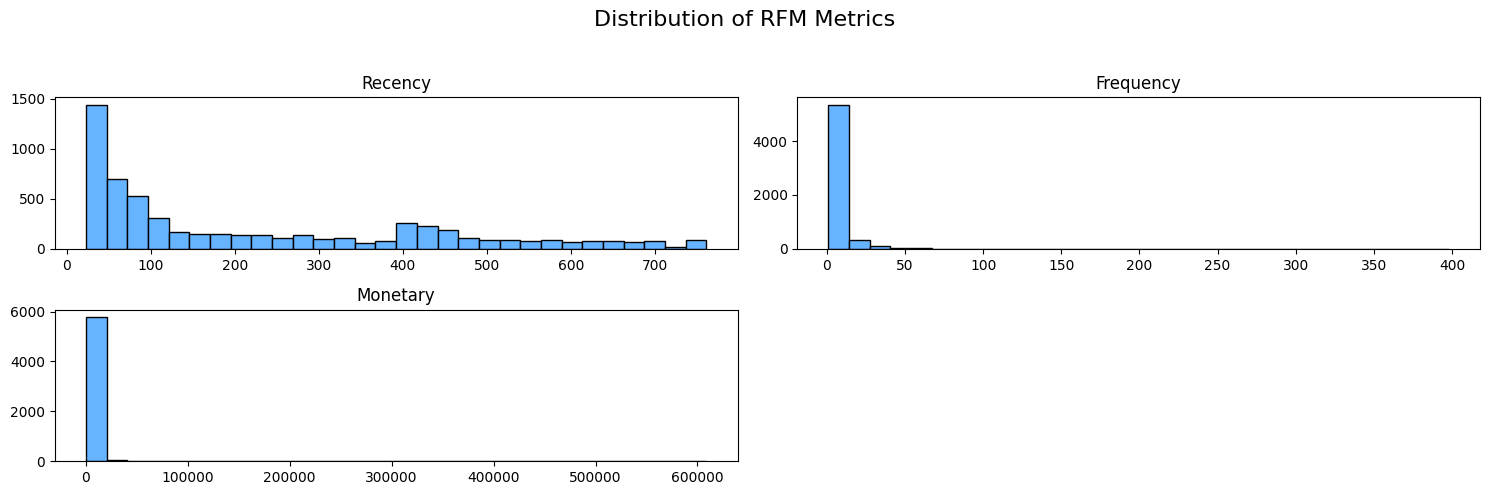

In [0]:
# Step 10: Plot distribution of Recency, Frequency, Monetary
import matplotlib.pyplot as plt

rfm_pdf = segmented.select("Recency","Frequency","Monetary").toPandas()
rfm_pdf.hist(
  bins=30, figsize=(15,5), grid=False,
  color='#66B3FF', edgecolor='black'
)
plt.suptitle('Distribution of RFM Metrics', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


/databricks/spark/python/pyspark/sql/connect/expressions.py:1061: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


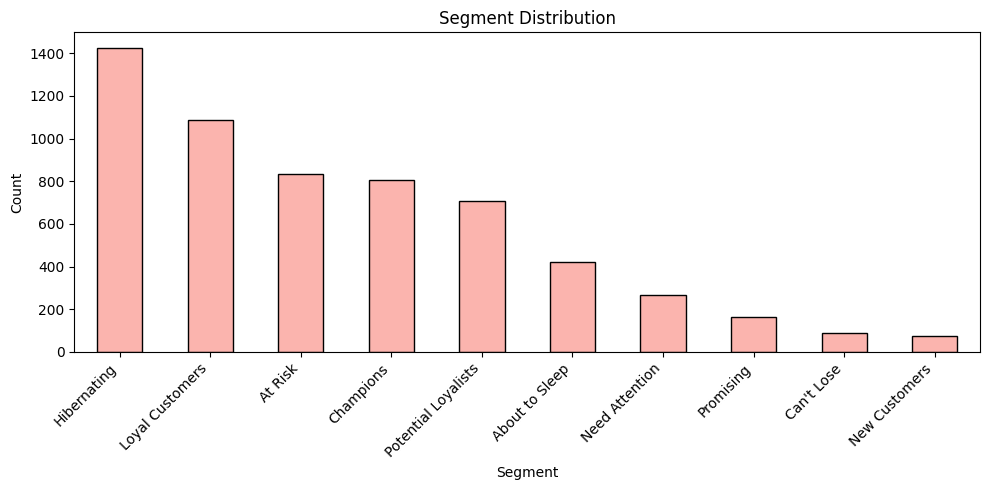

In [0]:
# Step 11: Bar chart of segment counts
seg_counts = segmented.groupBy("Segment") \
                      .count() \
                      .toPandas() \
                      .sort_values("count", ascending=False)

seg_counts.plot(
  kind='bar',
  x='Segment', y='count',
  figsize=(10,5),
  colormap='Pastel1',
  edgecolor='black',
  legend=False
)
plt.title('Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [0]:
%pip install squarify

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


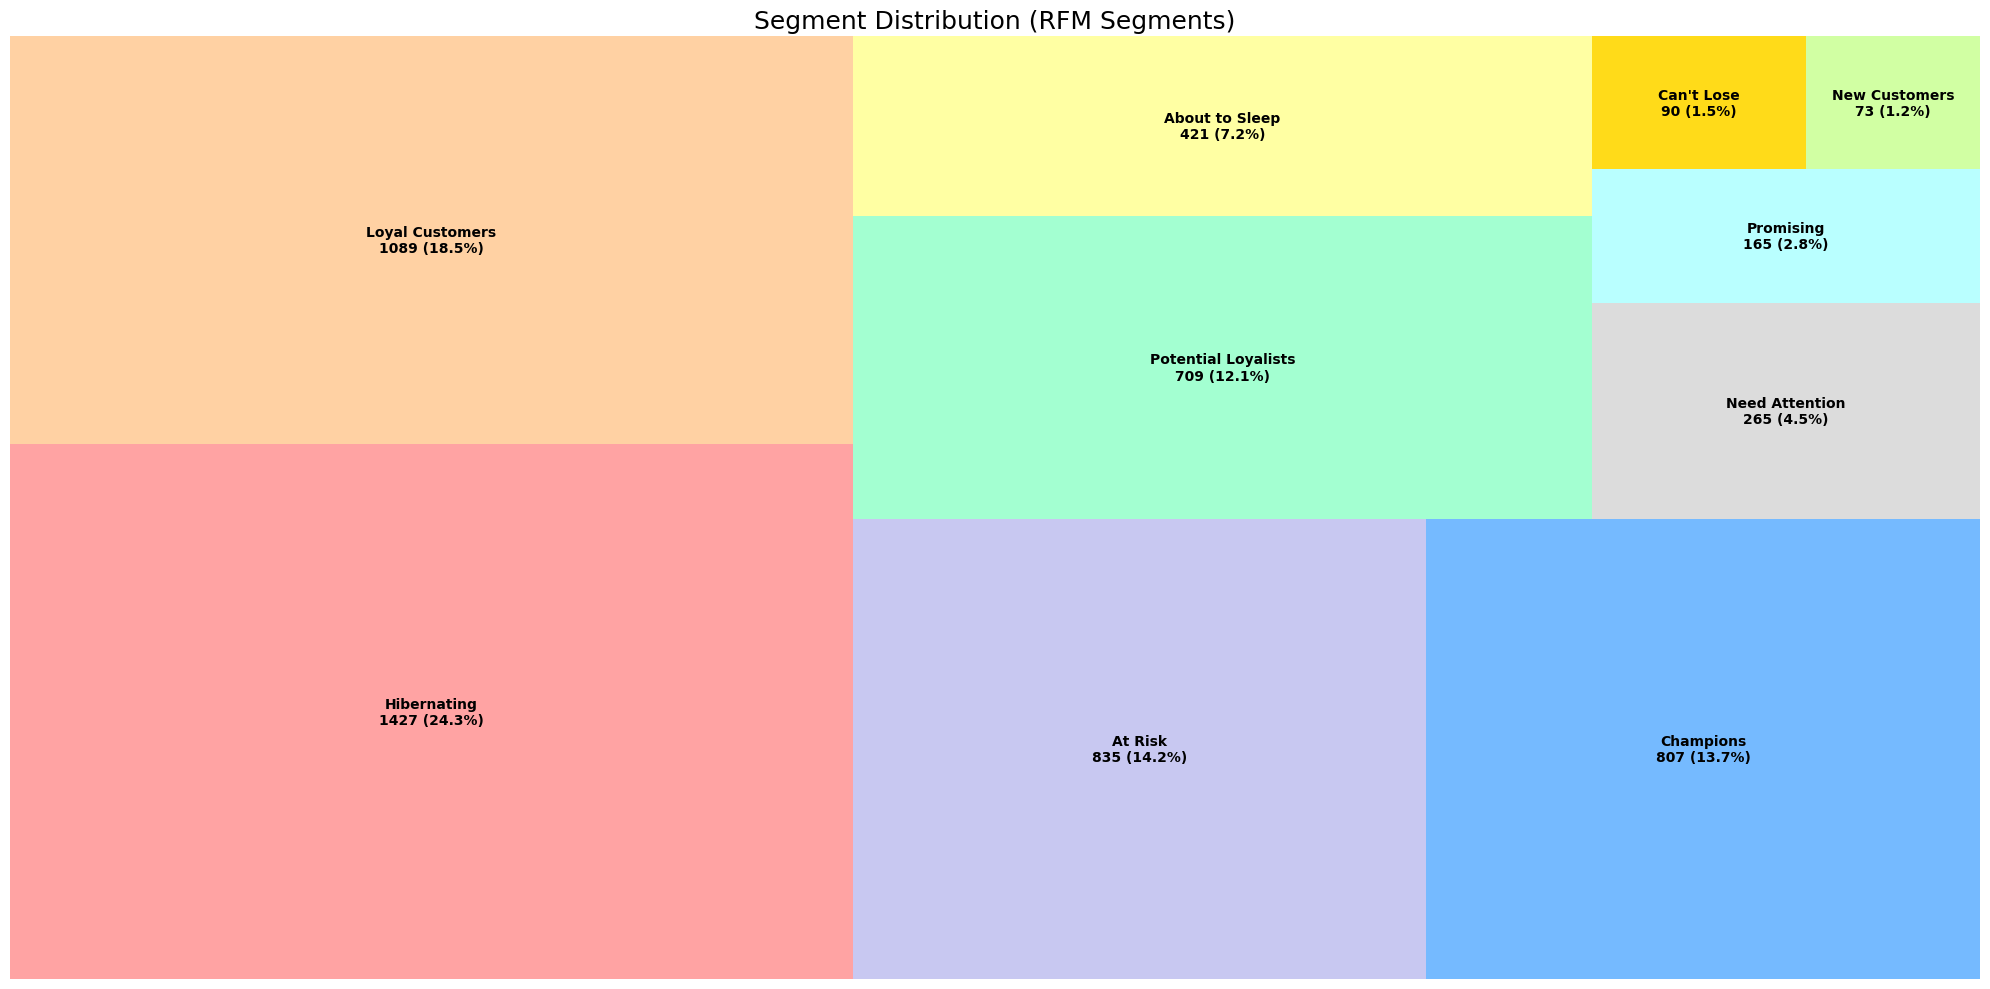

In [0]:
import squarify

sizes = seg_counts['count'].values
total = sizes.sum()
labels = [
  f"{row['Segment']}\n{row['count']} ({row['count']/total*100:.1f}%)"
  for _, row in seg_counts.iterrows()
]
colors = [
  '#FF9999','#FFCC99','#C2C2F0','#66B3FF','#99FFCC',
  '#FFFF99','#D9D9D9','#B2FFFF','#FFD700','#CCFF99'
][:len(sizes)]

plt.figure(figsize=(20,10))
squarify.plot(
  sizes=sizes, label=labels, alpha=0.9, color=colors,
  text_kwargs={'weight':'bold'}
)
plt.title('Segment Distribution (RFM Segments)', fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.show()